In [41]:
import pandas as pd
import numpy as np
import joblib
import os

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

In [2]:
df = pd.read_csv("clean/appointment_cleaned.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (109545, 24)


,specialty,gender,no_show,disability,appointment_shift,age,under_12_years_old,over_60_years_old,patient_needs_companion,average_temp_day,...,storm_day_before,rain_intensity,heat_intensity,Hipertension,Diabetes,Alcoholism,Handcap,Scholarship,SMS_received,appointment_datetime
0,1,0,1,0,1,9,1,0,1,23.18,...,1,1,3,0,0,0,0,0,0,2020-01-01 17:00:00
1,1,1,0,0,2,11,1,0,1,14.31,...,1,1,2,0,0,0,0,0,0,2020-01-01 07:00:00
2,2,1,0,0,1,8,1,0,1,21.61,...,1,1,3,0,0,0,0,0,0,2020-01-01 16:00:00
3,2,1,1,0,1,9,1,0,1,21.39,...,1,2,1,0,0,0,0,0,1,2020-01-01 14:00:00
4,3,1,0,1,2,12,0,0,0,20.15,...,1,1,1,0,0,0,0,0,0,2020-01-01 08:00:00


In [21]:
# Convert appointment_datetime to datetime
df['appointment_datetime'] = pd.to_datetime(
    df['appointment_datetime'],
    errors='coerce'
)

# Check datatype
print(df['appointment_datetime'].dtype)

# Check invalid/missing datetime
print(
    "Missing datetime:",
    df['appointment_datetime'].isnull().sum()
)

datetime64[ns]
Missing datetime: 0


In [22]:
df['appointment_date'] = df['appointment_datetime'].dt.date

daily_demand = (
    df.groupby('appointment_date')
      .size()
      .reset_index(name='appointment_count')
)

daily_demand['appointment_date'] = pd.to_datetime(
    daily_demand['appointment_date']
)

daily_demand = daily_demand.sort_values(
    'appointment_date'
).reset_index(drop=True)

daily_demand.head()

,appointment_date,appointment_count
0,2020-01-01,25
1,2020-01-02,33
2,2020-01-03,18
3,2020-01-04,16
4,2020-01-05,15


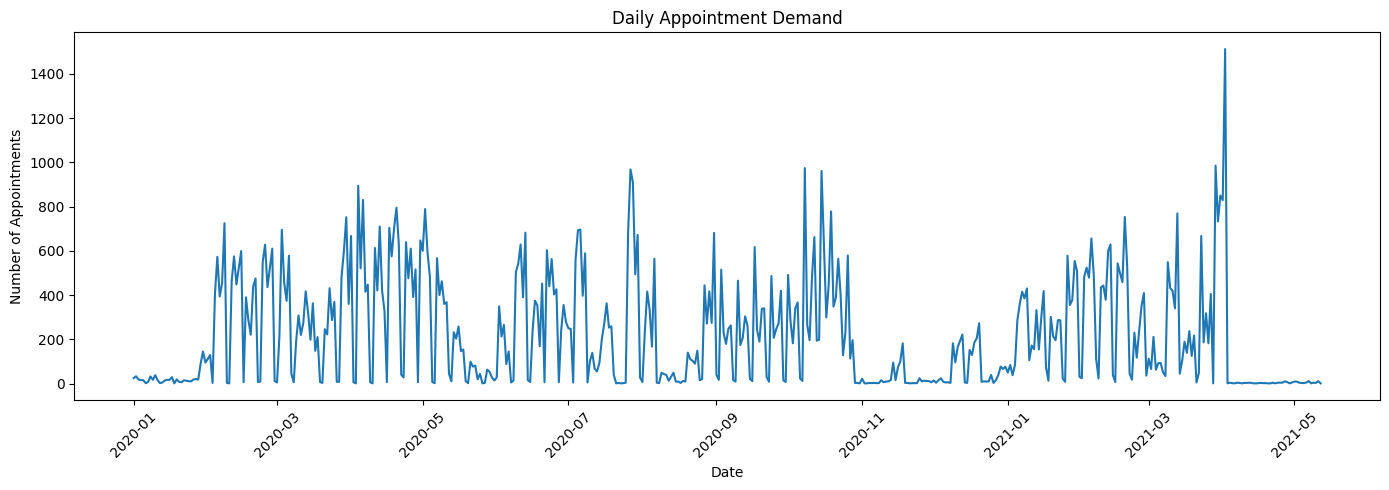

In [40]:
plt.figure(figsize=(14, 5))

plt.plot(
    daily_demand['appointment_date'],
    daily_demand['appointment_count']
)

plt.title("Daily Appointment Demand")
plt.xlabel("Date")
plt.ylabel("Number of Appointments")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Feature Engineering

In [27]:
daily_demand['year'] = (
    daily_demand['appointment_date'].dt.year
)

daily_demand['month'] = (
    daily_demand['appointment_date'].dt.month
)

daily_demand['day'] = (
    daily_demand['appointment_date'].dt.day
)

daily_demand['day_of_week'] = (
    daily_demand['appointment_date'].dt.dayofweek
)

daily_demand['week_of_year'] = (
    daily_demand['appointment_date']
    .dt.isocalendar()
    .week
    .astype(int)
)

In [28]:
daily_demand['lag_1'] = (
    daily_demand['appointment_count'].shift(1)
)

daily_demand['lag_7'] = (
    daily_demand['appointment_count'].shift(7)
)

daily_demand['lag_14'] = (
    daily_demand['appointment_count'].shift(14)
)

In [29]:
daily_demand['rolling_7'] = (
    daily_demand['appointment_count']
    .shift(1)
    .rolling(7)
    .mean()
)

daily_demand['rolling_14'] = (
    daily_demand['appointment_count']
    .shift(1)
    .rolling(14)
    .mean()
)

In [30]:
daily_demand['rolling_7'] = (
    daily_demand['appointment_count']
    .shift(1)
    .rolling(7)
    .mean()
)

daily_demand['rolling_14'] = (
    daily_demand['appointment_count']
    .shift(1)
    .rolling(14)
    .mean()
)

In [31]:
forecast_features = [
    'year',
    'month',
    'day',
    'day_of_week',
    'week_of_year',
    'lag_1',
    'lag_7',
    'lag_14',
    'rolling_7',
    'rolling_14'
]

X_forecast = forecast_df[forecast_features]

y_forecast = forecast_df['appointment_count']

print("Features:", X_forecast.shape)
print("Target:", y_forecast.shape)

Features: (484, 10)
Target: (484,)


In [32]:
split_index = int(len(forecast_df) * 0.80)

X_train_forecast = X_forecast.iloc[:split_index]
X_test_forecast = X_forecast.iloc[split_index:]

y_train_forecast = y_forecast.iloc[:split_index]
y_test_forecast = y_forecast.iloc[split_index:]

In [34]:
print("Training period:")
print(
    forecast_df['appointment_date'].iloc[0],
    "to",
    forecast_df['appointment_date'].iloc[split_index - 1]
)

print("\nTesting period:")
print(
    forecast_df['appointment_date'].iloc[split_index],
    "to",
    forecast_df['appointment_date'].iloc[-1]
)

Training period:
2020-01-15 00:00:00 to 2021-02-04 00:00:00

Testing period:
2021-02-05 00:00:00 to 2021-05-12 00:00:00


In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

models = {
    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBRegressor(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )
}

In [37]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

results = []

for name, model in models.items():

    model.fit(X_train_forecast, y_train_forecast)

    y_pred = model.predict(X_test_forecast)

    mae = mean_absolute_error(y_test_forecast, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_forecast, y_pred))
    mape = mean_absolute_percentage_error(
        y_test_forecast, y_pred
    ) * 100
    r2 = r2_score(y_test_forecast, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "R2": r2
    })

results_df = pd.DataFrame(results)

results_df.round(3)

,Model,MAE,RMSE,MAPE,R2
0,Linear Regression,173.959,259.732,4065.148,0.163
1,Random Forest,170.175,256.615,3751.644,0.183
2,XGBoost,188.360,287.777,4147.915,-0.028


In [39]:
# R2 highest wale model ko select karo
best_model_name = results_df.loc[
    results_df["R2"].idxmax(),
    "Model"
]

best_model = models[best_model_name]

print("Best Model:", best_model_name)


joblib.dump(
    best_model,
    "models/best_demand_forecasting_model.pkl"
)

print("Model saved successfully!")

Best Model: Random Forest
Model saved successfully!
